# Stage 3 — Hydrological Connectivity (Mole Creek prototype)

Answers a different question from Stage 2: not "where is karst?" but "where could something happening at the surface reach the karst?"

**Score: D8 flow routing.** For each karst polygon, count how many DEM cells drain into it (WhiteboxTools D8 routing on the 25 m DEM, run in `03alt3_hydrological_connectivity`), divided by the polygon's own cell count. That ratio is classed **on a log scale, in powers of ten**: up to 1, 1 to 10, 10 to 100 and over 100 upstream cells per polygon cell, giving classes 1 (lowest) to 4 (highest), which are rescaled to the 0-3 scale the later stages expect. The routing resolution is compared in Stage 13 (2 m against 25 m at Mole Creek, 100 m statewide).

**Archived Atlas score.** The first connectivity score used the Karst Atlas flags (the highest of exposure type, proximal catchment, distal catchment). It is archived: it is computed below only because polygons the routing cannot score keep it as a fallback, and because Stage 13 uses it as a check on the routing. The notebooks that compared it as a second version are in `notebooks/archive/`.

**Boundary:** the Mole Creek study boundary (Stage 0) is buffered by 3 km, because the unbuffered union of karst polygons was 99.9997% covered by karst/catchment features, leaving no surrounding land. Routing covers the Mole Creek karst polygons only; polygons in the buffer, which are context, keep their Atlas score.

In [1]:
from pathlib import Path
import os
import sys
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import add_connectivity, add_connectivity_d8, rasterize_max
from mapping import add_attribution, add_basemap, data_bounds, finish_map, plot_scores, raster_extent, scores_legend

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

# Reads Stage 2's output, not Stage 1's -- each stage now has its own file
karst_mc = gpd.read_file(str(outpath / "karst_mc_susceptibility_EPSG7855.gpkg"))
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# D8 upstream counts for the Mole Creek karst polygons (03alt3, 25 m DEM; shared output)
d8_counts_path = outpath / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.csv"
if not d8_counts_path.is_file():
    raise FileNotFoundError(f"Run 03alt3_hydrological_connectivity first (or get the shared output): {d8_counts_path}")

## 3.1 Atlas-based connectivity score (archived; fallback and check)

Combines three signals via `add_connectivity()`, taking the **max** per
polygon (a polygon can be karst itself *and* separately flagged as a
catchment for an adjacent karst area — confirmed in the real data).

In [2]:
add_connectivity(karst_mc)

print("Atlas connectivity score distribution (polygon count):")
print(karst_mc["connectivity"].value_counts().sort_index())
print()
print("Which component drove each score, by exposure type:")
print(pd.crosstab(karst_mc["connectivity"], karst_mc["exposure_type"]))

Atlas connectivity score distribution (polygon count):
connectivity
0     5
2    18
3    67
Name: count, dtype: int64

Which component drove each score, by exposure type:
exposure_type  covered  exposed  interstratal  non-karst
connectivity                                            
0                    0        0             0          5
2                   18        0             0          0
3                    0       45            10         12


## 3.2 D8 flow-routing connectivity (main score)

`add_connectivity_d8()` joins the routed ratio (upstream cells per polygon cell) onto each karst polygon and classes it at powers of ten: **class 1** is a ratio of up to 1 (little more than the polygon's own ground drains in), **class 2** is 1 to 10, **class 3** is 10 to 100 and **class 4** is over 100 (hundreds of times its own area: karst low in a big catchment). Each step is ten times the last, which suits a ratio that runs from 0 to over 100,000. The edges are fixed, so a class means the same ratio at 2 m, 25 m and 100 m and no single large catchment sets the scale. The class is scaled to 0-3 as `3 * class / 4`. The Atlas score stays in `connectivity_atlas`.

In [3]:
add_connectivity_d8(karst_mc, d8_counts_path, scheme="decades")

routed = karst_mc["connectivity_source"] == "d8"
edges = karst_mc.attrs["d8_ratio_edges"]
print("Class edges (upstream cells per polygon cell):", [float(e) for e in edges])
print(f"Polygons routed: {routed.sum()}; polygons keeping their Atlas score (buffer context, not reported): {(~routed).sum()}")
print()
print("D8 class distribution, routed polygons:")
print(karst_mc.loc[routed, "d8_class"].value_counts().sort_index().astype(int).rename("polygons").to_string())
print()
print("D8 class by Atlas connectivity score, routed polygons (rows: D8 class, columns: Atlas score):")
print(pd.crosstab(karst_mc.loc[routed, "d8_class"].astype(int), karst_mc.loc[routed, "connectivity_atlas"]))

karst_mc.to_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg", driver="GPKG")

Class edges (upstream cells per polygon cell): [1.0, 10.0, 100.0]
Polygons routed: 66; polygons keeping their Atlas score (buffer context, not reported): 24

D8 class distribution, routed polygons:
d8_class
1.0     9
2.0    41
3.0    12
4.0     4

D8 class by Atlas connectivity score, routed polygons (rows: D8 class, columns: Atlas score):
connectivity_atlas  2.0  3.0
d8_class                    
1                     1    8
2                    10   31
3                     4    8
4                     2    2


## 3.3 Rasterise onto the Stage 1 DEM template

Any cell not covered by a karst/catchment polygon at all correctly falls back to 0 (real background land, now that the boundary includes it). Uses `rasterize_max()` -- see Stage 2's note on why. The D8 scores are fractional, so that raster is written as float32; the archived Atlas raster stays integer.

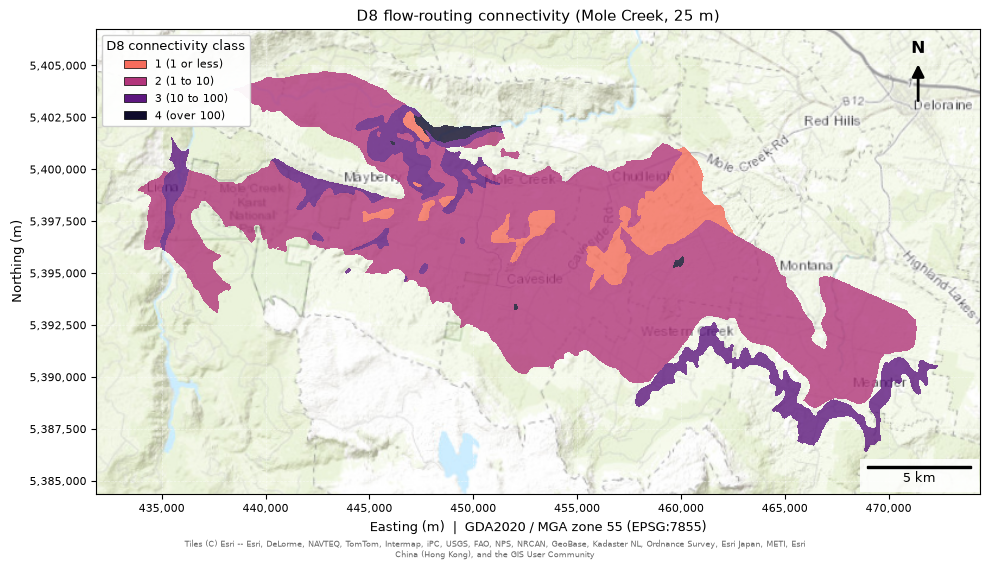

In [4]:
with rasterio.open(str(outpath / "dem_mc_EPSG7855.tif")) as dem_src:
    template_transform = dem_src.transform
    template_shape = (dem_src.height, dem_src.width)
    template_crs = dem_src.crs

# Main score (D8, log classes): float 0-3
connectivity_raster = rasterize_max(karst_mc, "connectivity", template_shape, template_transform, dtype="float32")
profile_d8 = {
    "driver": "GTiff", "height": template_shape[0], "width": template_shape[1],
    "count": 1, "dtype": "float32", "crs": template_crs, "transform": template_transform, "nodata": -9999,
}
with rasterio.open(outpath / "connectivity_mc_EPSG7855.tif", "w", **profile_d8) as dst:
    dst.write(connectivity_raster, 1)

# Version 2 (Atlas): integer 0-3
connectivity_atlas_raster = rasterize_max(karst_mc, "connectivity_atlas", template_shape, template_transform)
profile_atlas = dict(profile_d8, dtype="uint8", nodata=255)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif", "w", **profile_atlas) as dst:
    dst.write(connectivity_atlas_raster, 1)

# D8 class raster (0 = not routed) for the map
karst_mc["d8_class_map"] = karst_mc["d8_class"].fillna(0).astype(int)
d8_class_raster = rasterize_max(karst_mc, "d8_class_map", template_shape, template_transform)

D8_LABELS = ["Not routed", "1 (1 or less)", "2 (1 to 10)", "3 (10 to 100)", "4 (over 100)"]
bounds = data_bounds(d8_class_raster > 0, template_transform)
fig, ax = plt.subplots(figsize=(10, 5.6))
add_basemap(ax, bounds, zoom=11)
plot_scores(ax, d8_class_raster, template_transform, len(D8_LABELS))
scores_legend(ax, D8_LABELS, title="D8 connectivity class")
ax.set_title("D8 flow-routing connectivity (Mole Creek, 25 m)", fontsize=11)
finish_map(ax)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(Path("..") / "figures" / "connectivity.png", dpi=200, bbox_inches="tight")
plt.show()

## Stage 3 outputs

- `connectivity_mc_EPSG7855.tif` — main connectivity raster, D8 log classes (float32, 0-3); read by Stage 4
- `connectivity_atlas_mc_EPSG7855.tif` — archived Atlas connectivity raster (0-3), read only by the archived notebooks
- `karst_mc_connectivity_EPSG7855.gpkg` — Stage 2's data plus connectivity columns: `connectivity` (main, D8), `connectivity_atlas` (archived Atlas score), `d8_ratio`, `d8_class`, `connectivity_source` (the complete Mole Creek karst vector used by later stages)

**What the two scores measure.** The D8 ratio counts water arriving into a polygon from upslope, so it rewards karst low in a large catchment. The Atlas flags mark the polygons whose own catchment drains onto karst, which is the source side. They agree only weakly (rank correlation about -0.2 across the 66 Mole Creek polygons), and the like-for-like check in Stage 13 shows that most of the upstream cells reaching a polygon do lie in Atlas proximal catchments.

**Limitations.** Routing depends on DEM resolution (Stage 13 compares 2 m, 25 m and 100 m), the class edges are fixed powers of ten, so they are a choice rather than something fitted to the data. The Atlas score is archived in `connectivity_atlas`.

**Next (Stage 4):** combine Stage 2 (susceptibility) × Stage 3 (connectivity) into intrinsic karst vulnerability, still at the Mole Creek prototype stage, before Stage 5 introduces land-use pressure.